# Reconstruct Stokes profile from ERA5 wave output
- Author: Muxin Hu
- created time: 12.04.2026
- modified time: 13.04.2026

The vertical structure of the Stokes drift is reconstructed following the parameterization of **Breivik et al. (2014)**, which approximates the Stokes drift profile in terms of two wave parameters: the Stokes transport ($\mathbf V_s$) and the surface Stokes drift velocity ($\mathbf u_s(0)$). 

**The Stokes drift velocity as a function of depth $z$** is given by:
\begin{equation}
    \mathbf {u}_s(z)=\mathbf {u}_s(0)\frac{e^{2k_ez}}{1-Ck_ez} \tag{1}
\end{equation}
where:
\begin{equation}
    C\approx 8 \tag{2}
\end{equation}
and the **inverse depth scale $k_e$** is defined as
\begin{equation}
    k_e =\frac{\mathbf {u}_s(0)[e^{1/4}E_1(1/4)]}{8\mathbf V_s},\quad \text{with}\quad e^{1/4}E_1(1/4)\approx 1.34. \tag{3}
\end{equation}
Here, $E_1$ denotes the exponential integral. The **Stokes transport ($\mathbf V_s$) can be approximated from bulk wave parameters** as:
\begin{equation}
    \mathbf{V_s}\approx \frac{\pi H_s^2}{8 \overline{T}} \hat{\mathbf {k}}_s \tag{4}
\end{equation}
Where $H_s$ is the significant wave height, $\overline{T}$ is the mean wave period, and $\hat{\mathbf {k}}_s$ is the unit vector in the mean wave propagation direction. 

In [1]:
import xarray as xr
import numpy as np
import pyicon as pyic
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import cmocean as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
%matplotlib inline

----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.


ERROR 1: PROJ: proj_create_from_database: Open of /home/m/m301254/.conda/envs/env02_waves/share/proj failed


----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


## Read Data

In [2]:
# read data
wave_globe = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/era5_SurfWaves_global_1979-2025.grib",engine="cfgrib")

In [4]:
wave_globe

<xarray.Dataset> Size: 6GB
Dimensions:     (time: 564, latitude: 361, longitude: 720)
Coordinates:
  * time        (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2025-12-01
  * latitude    (latitude) float64 3kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    meanSea     float64 8B ...
    valid_time  (time) datetime64[ns] 5kB ...
Data variables:
    mwd         (time, latitude, longitude) float32 586MB ...
    mwp         (time, latitude, longitude) float32 586MB ...
    swh         (time, latitude, longitude) float32 586MB ...
    mdts        (time, latitude, longitude) float32 586MB ...
    mdww        (time, latitude, longitude) float32 586MB ...
    mpts        (time, latitude, longitude) float32 586MB ...
    mpww        (time, latitude, longitude) float32 586MB ...
    shts        (time, latitude, longitude) float32 586MB ...
    shww        (time, latitude, longitude) float32 586MB ...
    ust         (time, latitude, longitude) float32 586MB ...
    vst         (time, latitude, longitude) float32 586MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-13T21:21 GRIB to CDM+CF via cfgrib-0.9.1...

## Estimate: Stokes transport
from either:
- Separately estimated from (1) wind wave and (2) total swells
- directly estimated from combined wind waves and swell

In [5]:
# Estimate the Stokes transport (unit: m^2/s)
def estimate_stokes_transport(Hs, T, theta_from_deg):
    """
    theta_drom_deg: the raw ERA5 data are degrees that waves are coming FROM, 
    so zero means 'coming from the north' and 90 'coming from the east'.
    """
    # convert coming from to propagating toward
    theta = np.deg2rad((theta_from_deg + 180) % 360)

    Vs_mag = np.pi * Hs**2 / (8 * T)
    Vs_u = Vs_mag * np.sin(theta) # eastward
    Vs_v = Vs_mag * np.cos(theta) # northward

    return Vs_u, Vs_v

# Separately estimated from wind wave and swell
# Wind wave (ww)
Vst_u_ww, Vst_v_ww = estimate_stokes_transport(wave_globe["shww"], wave_globe["mpww"], wave_globe["mdww"])
# Total Swells (ts)
Vst_u_ts, Vst_v_ts = estimate_stokes_transport(wave_globe["shts"], wave_globe["mpts"], wave_globe["mdts"])
# combine
Vst_u = Vst_u_ww + Vst_u_ts
Vst_v = Vst_v_ww + Vst_v_ts

# directly estimated from mean wave direction/period/height
Vst_u_direct, Vst_v_direct = estimate_stokes_transport(wave_globe["swh"], wave_globe["mwp"], wave_globe["mwd"])

## inverse depth scale: $k_e$

- Formula: $k_e =\frac{\mathbf {u}_s(0)[e^{1/4}E_1(1/4)]}{8\mathbf V_s},\quad \text{with}\quad e^{1/4}E_1(1/4)\approx 1.34 $
- Steps:
    1. **Compute surface Stokes drift magnitude and unit direction**: $∣u_s​(0)∣=\sqrt{u_{st}^2​+v_{st}^2​}
​$, $\hat e = \frac{u_s(0)}{∣u_s​(0)∣}$
    2. **Project transport onto surface Stokes drift direction**: $\mathbf V_{st}'=\mathbf V_{st}\cdot \hat e$, to ensure consistency between transport magnitude and profile direction
    3. **Compute inverse depth scale**: $k_e \approx \frac{1.34∣u_s​(0)∣}{8\mathbf V_{st}'}$

In [8]:
# compute surface stokes drift magnitude and unit direction
ust = wave_globe["ust"]
vst = wave_globe["vst"]
us_mag = np.sqrt(ust**2 + vst**2)
# avoid division by zero
eps = 1e-12
e_u = ust / (us_mag + eps)
e_v = vst / (us_mag + eps)

### For $\mathbf V_s$ from combined wave

In [9]:
# project transport onto surface Stokes drift direction
V_parallel_direct = Vst_u_direct * e_u + Vst_v_direct * e_v # ensure the direction is the correction of surface Stokes drift velocity

In [10]:
# compute the inverse depth scale
ke_direct = 1.34 * us_mag / (8 * (V_parallel_direct + eps))

### For $\mathbf V_s$ from separated waves (ww, ts)

In [11]:
V_parallel_total = Vst_u * e_u + Vst_v * e_v
ke_total = 1.34 * us_mag / (8 * (V_parallel_total + eps))

In [24]:
print(ke_direct.shape)
print(np.nanmean(ke_direct.values))
print(np.nanmean(ke_total.values))

(564, 361, 720)
0.060055852
0.15201841


### Climatological field of near-surface e-folding depth ($1/2k_e$)

In [34]:
depth_direct = 1 / (2 * ke_direct)
depth_total = 1 / (2 * ke_total)

# climatologies: annual
depth_direct_clim = depth_direct.mean(dim="time")
depth_total_clim = depth_total.mean(dim="time")

# climatologies: JJA and DJF
depth_direct_clim_JJA = depth_direct.sel(time=depth_direct.time.dt.season == "JJA", drop=True).mean(dim="time")
depth_direct_clim_DJF = depth_direct.sel(time=depth_direct.time.dt.season == "DJF", drop=True).mean(dim="time")

depth_total_clim_JJA = depth_total.sel(time=depth_total.time.dt.season == "JJA", drop=True).mean(dim="time")
depth_total_clim_JJA = depth_total.sel(time=depth_total.time.dt.season == "JJA", drop=True).mean(dim="time")
depth_total_clim_DJF = depth_total.sel(time=depth_total.time.dt.season == "DJF", drop=True).mean(dim="time")
depth_total_clim_DJF = depth_total.sel(time=depth_total.time.dt.season == "DJF", drop=True).mean(dim="time")

In [43]:
def plot_divergence_panel(ax, da, title, vmin, vmax, cmap="RdBu_r"):
    """
    Plot a single convergence panel
    
    Parameters:
    -------------
    ax: matplotlib axix
    da: 2D dataArray (lat, lon)
    title: subplot title
    """
    im = ax.pcolormesh(da.longitude, da.latitude, da, 
                       cmap=cmap, vmin=vmin, vmax=vmax, 
                       shading="auto",
                       transform=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.7)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.set_title(title, loc="left", fontsize=14)
    # ax.gridlines(draw_labels=False, linewidth=0.3)
    return im

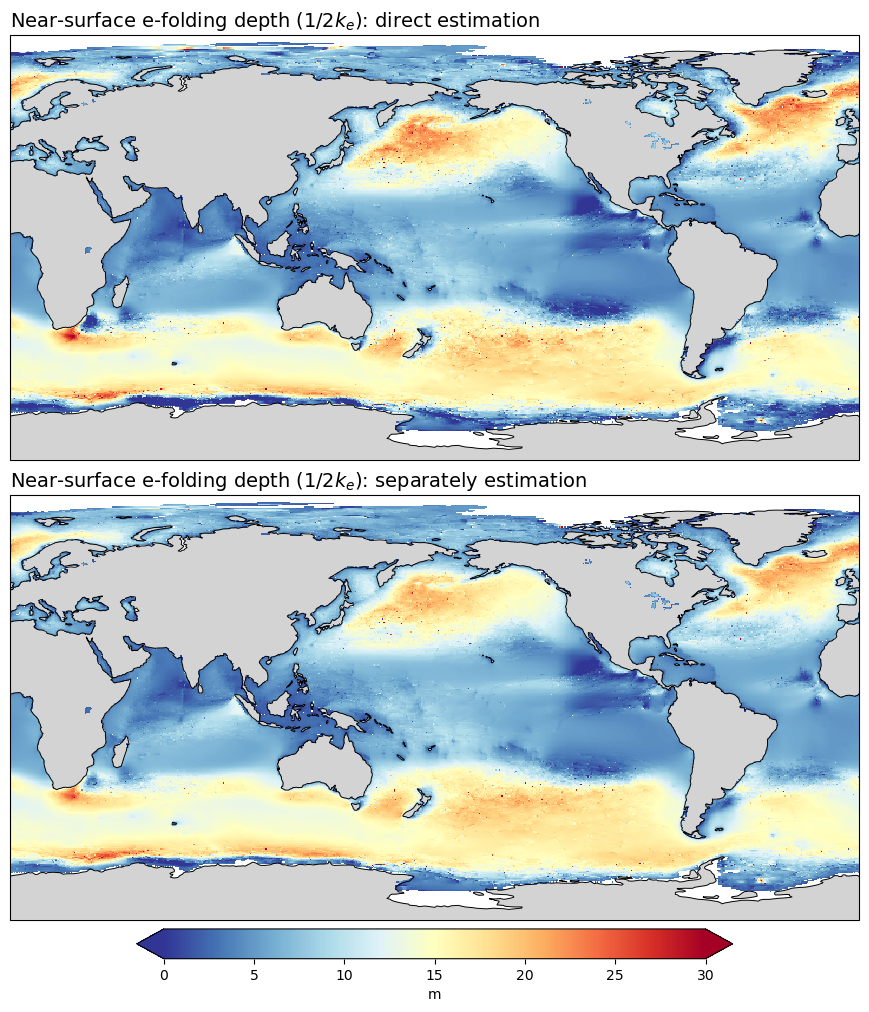

In [45]:
fig, axes = plt.subplots(2,1, figsize=(12, 10),
                         subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
                         constrained_layout=True)

im0 = plot_divergence_panel(axes[0], depth_direct_clim, r"Near-surface e-folding depth ($1/2k_e$): direct estimation", 0, 30, cmap="RdYlBu_r")
im1 = plot_divergence_panel(axes[1], depth_total_clim, r"Near-surface e-folding depth ($1/2k_e$): separately estimation", 0, 30, cmap="RdYlBu_r")

cbar1 = fig.colorbar(im1, ax=axes[1], orientation="horizontal", pad=0.02, shrink=0.5, extend="both")
cbar1.set_label("m")

save_path = "/home/m/m301254/project_surfwaves/figs/era5_Stokes_transport"
plt.savefig(f"{save_path}/Estimated_efolding_depth_for_Stokes_drift_profile.png", dpi=150 ,bbox_inches="tight")

e-folding depth scale: $\delta \sim 1/2k_e$ provides a measure of the near-surface penetration of the Stokes drift, indicatinf **how deep the core influence reaches**

## Reconstruct Stokes drift profile
- Original formula in Breivik et al. (2014): $\mathbf {u}_s(z)=\mathbf {u}_s(0)\frac{e^{2k_ez}}{1-Ck_ez}$
- **Modified**: $\mathbf {u}_s(z)=\hat e |\mathbf {u}_s(0)|\frac{e^{2k_ez}}{1-Ck_ez}$